# Avance Fase 3 — Semana 2
## Núcleo algorítmico y Programación Orientada a Objetos aplicado a Airbnb Santiago

**Curso:** MCDI500 — Programación para la Ciencia de Datos · **Programa:** Magíster en Ciencia de Datos e IA, UNAB  
**Proyecto Grupo 3:** Análisis reproducible de precios de alojamientos Airbnb en Santiago

---

> **Propósito del notebook**  
> Aplicación de Programación Orientada a Objetos y Eficiencia Computacional al Análisis de Airbnb
El propósito de este notebook es aplicar conceptos de programación orientada a objetos, preprocesamiento, recursividad y eficiencia computacional sobre el conjunto de datos de Airbnb Santiago, manteniendo la continuidad con las fases anteriores del proyecto y preparando los datos para el análisis de la pregunta del informe: **¿Qué características observables de los alojamientos (ubicación, anfitrión, comuna, etc.) se relacionan con las diferencias de precio?**



## Contenido


1. Los 5 conceptos que necesitas (en 1 minuto)
2. Tu primera clase: `Preprocesador`
3. Ejecucion del Pipeline y Conservacion de la base de   analisis
4. Herencia: reutilizar y especializar
5. Recursividad (idea simple)
6. Eficiencia: ¿por qué evitar bucles?
7. Cómo aplicar esto a **tu** proyecto
8. Bibliografía


## 1. Los conceptos que realizamos

| Concepto | Qué es | En nuestro ejemplo |
|---|---|---|
| **Clase** | El molde o plantilla. | `class Preprocesador:` |
| **Objeto** | Algo creado a partir de la clase. | `prep = Preprocesador("datos.csv")` |
| **Atributo** | Un dato que vive dentro del objeto. | `self.df` (la tabla) |
| **Método** | Una acción del objeto (una función dentro de la clase). | `prep.limpiar()` |
| **`self`** | La palabra que usa el objeto para referirse **a sí mismo**. | `self.df = ...` |

Y un método especial: **`__init__`** es el **constructor**: se ejecuta automáticamente cuando creas el
objeto y sirve para dejar listos sus atributos iniciales.


## 2. Clase `PreprocesadorAirbnb`

En esta etapa se implementa la clase `PreprocesadorAirbnb`, cuyo propósito es **organizar y encapsular el flujo de procesamiento de los datos** utilizado en el proyecto. Mediante sus métodos se integran operaciones de carga, exploración, limpieza, transformación, codificación, estandarización y validación.

Como archivo de entrada se utiliza **`airbnb_procesado_lipieza(1).xls`**, generado a partir del trabajo realizado en la Fase 2. Este conjunto contiene **17 variables previamente seleccionadas y depuradas**, manteniendo variables categóricas originales como **comuna, tipo de propiedad y tipo de habitación**, necesarias para continuar el análisis de las características relacionadas con las diferencias en el precio por noche.

> **Importante:** aunque el archivo posee extensión `.xls`, su contenido se encuentra almacenado como **texto delimitado**, por lo que se carga mediante `pd.read_csv()`.

La implementación mediante una clase permite reunir los datos y las operaciones asociadas dentro de una misma estructura, favoreciendo un código **más ordenado, reutilizable y reproducible**.

Además, el notebook trabaja exclusivamente con los datos reales del proyecto. Si el archivo de entrada no se encuentra disponible, el programa genera una advertencia y detiene la carga, evitando reemplazarlo por datos sintéticos o diferentes a los utilizados por nuestro grupo N°3


In [1]:
import os
import re
import timeit
import tracemalloc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder, StandardScaler

%matplotlib inline
np.random.seed(42)

# Archivo depurado de la Fase 2 que conserva las variables categóricas originales.
RUTA_DATOS = "/content/airbnb_procesado_lipieza.xls"

# Variable central de la pregunta de investigación.
PRECIO = "precio_por_noche"



La clase siguiente mantiene los datos en `self.df`. Cada método cumple una función concreta. Además, guardamos una copia de los datos categóricos en `self.df_analisis` antes del One-Hot Encoding, porque **comuna, tipo de propiedad y tipo de habitación deben seguir siendo legibles para responder la pregunta del informe**.


In [2]:
class PreprocesadorAirbnb:
    """Preprocesa y analiza el dataset de Airbnb Santiago mediante POO."""

    def __init__(self, ruta):
        self.ruta = ruta
        self.df = None
        self.df_analisis = None
        self.scaler = None

    def cargar(self):
        """Carga el archivo procesado de Fase 2."""
        if not os.path.exists(self.ruta):
            raise FileNotFoundError(
                f"No se encontró '{self.ruta}'. Asegurese que la ruta es correcta, y la existencia del archivo."
            )
        # El archivo entregado tiene extensión .xls, pero su contenido es CSV.
        self.df = pd.read_csv(self.ruta)
        print(f"Datos cargados: {self.df.shape[0]:,} filas y {self.df.shape[1]} columnas")
        return self.df

    def explorar(self):
        """Muestra estructura, tipos, nulos, duplicados y estadística básica."""
        if self.df is None:
            raise ValueError("Primero debes ejecutar cargar().")
        print("Dimensiones:", self.df.shape)
        print("Duplicados:", int(self.df.duplicated().sum()))
        print("Nulos totales:", int(self.df.isna().sum().sum()))
        print()
        print("Tipos de datos:")
        print(self.df.dtypes)
        return self.df.describe(include="all").T

    def limpiar(self):
        """Valida la limpieza heredada de F2 y resuelve nulos/duplicados si aparecen."""
        if self.df is None:
            raise ValueError("Primero debes ejecutar cargar().")

        filas_antes = len(self.df)
        duplicados = int(self.df.duplicated().sum())
        if duplicados:
            self.df = self.df.drop_duplicates().copy()

        # Si aparecieran nulos numéricos, se imputan con mediana.
        nulos_imputados = 0
        for col in self.df.select_dtypes(include=np.number).columns:
            n = int(self.df[col].isna().sum())
            if n:
                self.df[col] = self.df[col].fillna(self.df[col].median())
                nulos_imputados += n

        # Si aparecieran nulos categóricos, se imputan con la moda.
        for col in self.df.select_dtypes(exclude=np.number).columns:
            n = int(self.df[col].isna().sum())
            if n:
                moda = self.df[col].mode(dropna=True)
                if not moda.empty:
                    self.df[col] = self.df[col].fillna(moda.iloc[0])
                    nulos_imputados += n

        print(f"Filas antes: {filas_antes:,} | después: {len(self.df):,}")
        print(f"Duplicados eliminados: {duplicados}")
        print(f"Nulos imputados: {nulos_imputados}")
        return self.df

    def guardar_base_analisis(self):
        """Conserva categorías originales para interpretar precio por comuna/tipo."""
        self.df_analisis = self.df.copy()
        print("Copia interpretable guardada en prep.df_analisis")
        return self.df_analisis

    @staticmethod
    def _nombre_seguro(texto):
        """Convierte una categoría en un nombre de columna simple y reproducible."""
        texto = str(texto).strip().replace("/", "_")
        texto = re.sub(r"[^0-9A-Za-zÁÉÍÓÚáéíóúÑñ]+", "_", texto)
        return texto.strip("_")

    def codificar(self, columna, prefijo):
        """Convierte una variable categórica en columnas 0/1 mediante One-Hot Encoding."""
        categorias = sorted(self.df[columna].astype(str).unique())
        encoder = OneHotEncoder(categories=[categorias], sparse_output=False,
                                handle_unknown="ignore")
        matriz = encoder.fit_transform(self.df[[columna]].astype(str))
        nombres = [f"{prefijo}_{self._nombre_seguro(c)}" for c in categorias]
        nuevas = pd.DataFrame(matriz, columns=nombres, index=self.df.index).astype(int)
        self.df = pd.concat([self.df.drop(columns=[columna]), nuevas], axis=1)
        print(f"'{columna}': {len(categorias)} categorías -> {len(nombres)} columnas")
        return self.df

    def escalar(self, columnas):
        """Estandariza variables numéricas explicativas; el precio se conserva en CLP."""
        self.scaler = StandardScaler().fit(self.df[columnas])
        self.df[columnas] = self.scaler.transform(self.df[columnas])
        print(f"Escaladas {len(columnas)} variables. Precio NO escalado: {PRECIO}")
        return self.df

    def validar(self):
        """Comprueba nulos, texto sin codificar y conservación del precio."""
        nulos = int(self.df.isna().sum().sum())
        texto = self.df.select_dtypes(exclude=np.number).columns.tolist()
        precio_ok = PRECIO in self.df.columns
        print("Nulos totales:", nulos)
        print("Columnas de texto sin codificar:", texto if texto else "ninguna")
        print("Precio disponible en CLP:", "sí" if precio_ok else "no")
        print("Dimensiones finales:", self.df.shape)
        return nulos == 0 and not texto and precio_ok

    def resumen_pregunta(self, top=10):
        """Resume precio por comuna y tipo de habitación usando categorías interpretables."""
        if self.df_analisis is None:
            raise ValueError("Ejecuta guardar_base_analisis() antes de codificar.")
        base = self.df_analisis

        por_comuna = (base.groupby("neighbourhood_cleansed")[PRECIO]
                      .agg(alojamientos="size", mediana="median", promedio="mean")
                      .sort_values("mediana")
                      .head(top))
        por_habitacion = (base.groupby("room_type")[PRECIO]
                          .agg(alojamientos="size", mediana="median", promedio="mean")
                          .sort_values("mediana"))
        return por_comuna, por_habitacion



## 3. Ejecucion del Pipeline y Conservacion de la base de analisis

Creamos un objeto y ejecutamos el pipeline en orden. Antes de codificar guardaremos `df_analisis`, porque esa versión conserva los nombres de comunas y tipos de alojamiento y permite interpretar directamente su relación con el precio.


In [3]:
# 1) Creamos el objeto
from pathlib import Path
cwd = Path.cwd()
ROOT = next((p for p in [cwd, *cwd.parents] if (p / ".git").exists() or (p / "requirements.txt").exists()), cwd)
DIR_PROCESADO = ROOT / "Data/Processed"

prep = PreprocesadorAirbnb( DIR_PROCESADO/ "airbnb_procesado_limpieza.csv" )

# 2) Cargamos y exploramos los datos
prep.cargar()
resumen_inicial = prep.explorar()
resumen_inicial.head(20)



Datos cargados: 17,687 filas y 17 columnas
Dimensiones: (17687, 17)
Duplicados: 107
Nulos totales: 0

Tipos de datos:
hosts_time_as_host_years         int64
neighbourhood_cleansed             str
property_type                      str
room_type                          str
accommodates                     int64
bathrooms                      float64
bedrooms                       float64
beds                           float64
price_quote_price_per_night    float64
number_of_reviews                int64
review_scores_rating           float64
review_scores_accuracy         float64
review_scores_cleanliness      float64
review_scores_checkin          float64
review_scores_communication    float64
review_scores_location         float64
review_scores_value            float64
dtype: object


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
hosts_time_as_host_years,17687.0,NaN,NaN,NaN,3.909764,3.599477,0.0,1.0,3.0,7.0,15.0
neighbourhood_cleansed,17687,31,Santiago,6884,NaN,NaN,NaN,NaN,NaN,NaN,NaN
property_type,17687,65,Entire rental unit,12288,NaN,NaN,NaN,NaN,NaN,NaN,NaN
room_type,17687,4,Entire home/apt,14424,NaN,NaN,NaN,NaN,NaN,NaN,NaN
accommodates,17687.0,NaN,NaN,NaN,3.122802,1.814495,1.0,2.0,3.0,4.0,16.0
bathrooms,17687.0,NaN,NaN,NaN,1.286312,0.721479,0.5,1.0,1.0,1.0,22.0
bedrooms,17687.0,NaN,NaN,NaN,1.428846,0.968525,0.0,1.0,1.0,2.0,50.0
beds,17687.0,NaN,NaN,NaN,2.099395,1.828959,1.0,1.0,2.0,3.0,57.0
price_quote_price_per_night,17687.0,NaN,NaN,NaN,118197.743175,1226123.547951,978.64,41500.0,59000.0,90781.0,97000045.0
number_of_reviews,17687.0,NaN,NaN,NaN,37.908633,67.198386,0.0,2.0,13.0,45.0,1388.0


In [4]:
# 3) Validamos/limpiamos la base proveniente de Fase 2
prep.limpiar()

# 4) Traducimos nombres de columnas al español
traduccion_columnas = {
    "hosts_time_as_host_years": "años_como_anfitrion",
    "neighbourhood_cleansed": "comuna",
    "property_type": "tipo_propiedad",
    "room_type": "tipo_habitacion",
    "accommodates": "capacidad_personas",
    "bathrooms": "baños",
    "bedrooms": "dormitorios",
    "beds": "camas",
    "number_of_reviews": "numero_evaluaciones",
    "review_scores_rating": "puntaje_general",
    "review_scores_accuracy": "puntaje_precision",
    "review_scores_cleanliness": "puntaje_limpieza",
    "review_scores_checkin": "puntaje_llegada",
    "review_scores_communication": "puntaje_comunicacion",
    "review_scores_location": "puntaje_ubicacion",
    "review_scores_value": "puntaje_calidad_precio",
    "price_quote_price_per_night": "precio_por_noche"
}
prep.df.rename(columns=traduccion_columnas, inplace=True)

# 4) Traducimos los tipos de habitación al español
traduccion_habitaciones = {
    "Entire home/apt": "Alojamiento completo",
    "Private room": "Habitación privada",
    "Shared room": "Habitación compartida",
    "Hotel room": "Habitación de hotel"
}

prep.df["tipo_habitacion"] = prep.df["tipo_habitacion"].replace(
    traduccion_habitaciones
)

# Comprobamos ANTES de codificar
print("Tipos de habitación:")
print(prep.df["tipo_habitacion"].value_counts())

# 6) Guardamos una copia interpretable antes del One-Hot Encoding
prep.guardar_base_analisis()

# 7) Codificamos variables categóricas
prep.codificar("comuna", "comuna")
prep.codificar("tipo_propiedad", "tipo")
prep.codificar("tipo_habitacion", "habitacion")

# 8) Escalamos variables numéricas explicativas
# El precio NO se escala para mantenerlo interpretable en CLP

columnas_escalar = [
    "años_como_anfitrion",
    "capacidad_personas",
    "baños",
    "dormitorios",
    "camas",
    "numero_evaluaciones",
    "puntaje_general",
    "puntaje_precision",
    "puntaje_limpieza",
    "puntaje_llegada",
    "puntaje_comunicacion",
    "puntaje_ubicacion",
    "puntaje_calidad_precio"
]

prep.escalar(columnas_escalar)

# 9) Validamos el resultado
print()
print("¿Tabla lista para el análisis?:", prep.validar())



Filas antes: 17,687 | después: 17,580
Duplicados eliminados: 107
Nulos imputados: 0
Tipos de habitación:
tipo_habitacion
Alojamiento completo     14348
Habitación privada        3125
Habitación compartida       59
Habitación de hotel         48
Name: count, dtype: int64
Copia interpretable guardada en prep.df_analisis
'comuna': 31 categorías -> 31 columnas
'tipo_propiedad': 65 categorías -> 65 columnas
'tipo_habitacion': 4 categorías -> 4 columnas
Escaladas 13 variables. Precio NO escalado: precio_por_noche

Nulos totales: 0
Columnas de texto sin codificar: ninguna
Precio disponible en CLP: sí
Dimensiones finales: (17580, 114)
¿Tabla lista para el análisis?: True


In [5]:
# La tabla transformada final vive en prep.df
print("Dimensiones finales:", prep.df.shape)
prep.df.head()



Dimensiones finales: (17580, 114)


,años_como_anfitrion,capacidad_personas,baños,dormitorios,camas,precio_por_noche,numero_evaluaciones,puntaje_general,puntaje_precision,puntaje_limpieza,...,tipo_Shared_room_in_hotel,tipo_Shared_room_in_rental_unit,tipo_Tiny_home,tipo_Tower,tipo_Windmill,tipo_Yurt,habitacion_Alojamiento_completo,habitacion_Habitación_compartida,habitacion_Habitación_de_hotel,habitacion_Habitación_privada
0,1.412564,-0.620299,-0.397444,-0.443495,-0.602081,45647.0,-0.536702,0.576945,0.502878,0.635588,...,0,0,0,0,0,0,0,0,0,1
1,-1.088789,-1.170744,-0.397444,-0.443495,-0.602081,19856.0,-0.447596,0.576945,0.502878,0.635588,...,0,0,0,0,0,0,0,0,0,1
2,0.578780,-0.069854,-0.397444,-0.443495,-0.056005,46776.0,1.304823,-0.174807,0.028739,0.218132,...,0,0,0,0,0,0,1,0,0,0
3,-0.810861,-1.170744,-0.397444,-0.443495,-0.602081,25572.0,-0.566404,0.229983,0.236175,0.245962,...,0,0,0,0,0,0,0,0,0,1
4,-0.255005,-0.069854,-0.397444,0.586716,-0.056005,107043.5,-0.566404,0.229983,0.236175,0.245962,...,0,0,0,0,0,0,1,0,0,0


### 3.1 Verificación de Variables Numéricas Estandarizadas

El siguiente gráfico de cajas (*boxplot*) permite verificar visualmente el resultado de la **estandarización de algunas variables numéricas explicativas** del conjunto de datos: capacidad de personas, baños, dormitorios y camas.

La estandarización transforma estas variables para que queden expresadas en una **escala comparable**, evitando que las diferencias entre sus unidades originales condicionen los análisis posteriores.

El gráfico permite observar la **distribución, dispersión y presencia de valores extremos** de cada variable después de aplicar la transformación. Los valores cercanos a cero representan observaciones próximas al promedio de cada variable, mientras que valores positivos o negativos indican observaciones por encima o por debajo de dicho promedio.

Esta visualización funciona como un **control del preprocesamiento realizado**, permitiendo comprobar que las variables fueron transformadas antes de continuar con las siguientes etapas del análisis.

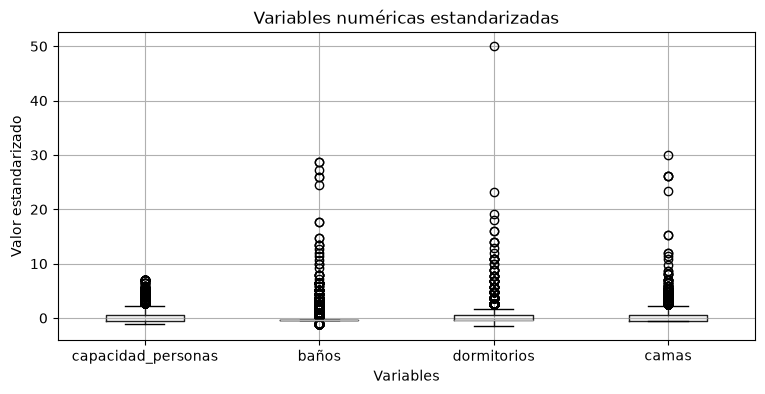

In [6]:
# Gráfico de control: variables explicativas estandarizadas
prep.df[
    ["capacidad_personas", "baños", "dormitorios", "camas"]
].boxplot(figsize=(9, 4))

plt.title("Variables numéricas estandarizadas")
plt.ylabel("Valor estandarizado")
plt.xlabel("Variables")
plt.show()


Interpretación del gráfico: El boxplot muestra que las variables estandarizadas se concentran principalmente alrededor de cero, lo que es consistente con el proceso de estandarización aplicado. Sin embargo, se observa una importante presencia de valores atípicos positivos, especialmente en las variables baños, dormitorios y camas. Destaca dormitorios, que presenta un valor extremadamente alejado del resto de las observaciones. Estos valores no deben considerarse automáticamente errores, ya que podrían corresponder a alojamientos reales con características poco frecuentes; sin embargo, resulta recomendable identificarlos y revisar su consistencia antes de utilizarlos en análisis posteriores.

### 4.1. Vinculación directa con la pregunta del informe

La POO (programacion orientada a objetos) organiza el procesamiento, pero el proyecto también debe mantener conexión con la problemática. Por eso usamos la copia `prep.df_analisis`, que conserva las categorías originales, para observar **cómo cambia el precio por comuna y tipo de habitación**. Se utiliza la **mediana** junto con el promedio porque el precio puede presentar valores extremos.

Este análisis es **descriptivo y exploratorio**: muestra diferencias y asociaciones observables, no causalidad.


In [7]:
# 4.1 Análisis del precio por comuna y tipo de habitación

# Recuperamos la base interpretable guardada antes del One-Hot Encoding
base = prep.df_analisis.copy()

# Análisis por comuna
por_comuna = (
    base.groupby("comuna")["precio_por_noche"]
    .agg(
        alojamientos="size",
        mediana="median",
        promedio="mean"
    )
    .sort_values("mediana")
    .head(10)
)

# Análisis por tipo de habitación
por_habitacion = (
    base.groupby("tipo_habitacion")["precio_por_noche"]
    .agg(
        alojamientos="size",
        mediana="median",
        promedio="mean"
    )
    .sort_values("mediana")
)

print("10 comunas con menor mediana de precio por noche:")
display(por_comuna.round(0))

print()

print("Precio por tipo de habitación:")
display(por_habitacion.round(0))



10 comunas con menor mediana de precio por noche:


,alojamientos,mediana,promedio
comuna,,,
Pedro Aguirre Cerda,5,25051.0,39829.0
Renca,33,29440.0,54003.0
Lo Prado,16,29882.0,43603.0
El Bosque,8,33882.0,41610.0
Quilicura,30,36614.0,53424.0
Cerro Navia,3,36992.0,43801.0
Quinta Normal,54,37227.0,38280.0
Estación Central,429,39941.0,46964.0
Maipú,87,40485.0,48321.0



Precio por tipo de habitación:


,alojamientos,mediana,promedio
tipo_habitacion,,,
Habitación compartida,59,20541.0,34104.0
Habitación privada,3125,34235.0,98518.0
Alojamiento completo,14348,64997.0,122952.0
Habitación de hotel,48,111772.0,164902.0


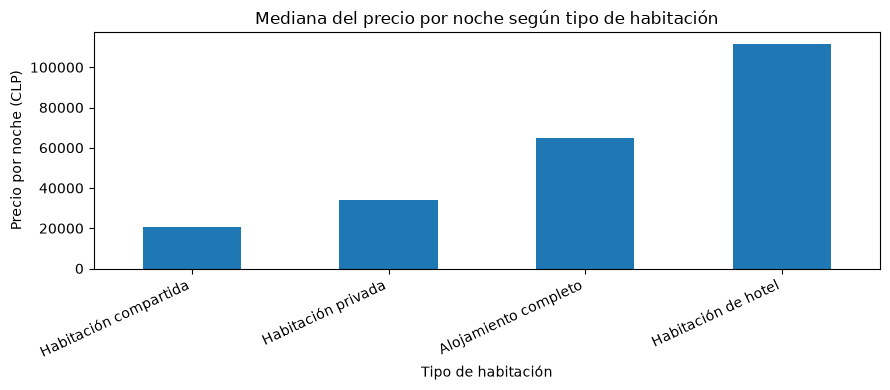

In [8]:
# Comparación visual de la mediana del precio por tipo de habitación

mediana_habitacion = (
    prep.df_analisis
    .groupby("tipo_habitacion")["precio_por_noche"]
    .median()
    .sort_values()
)

mediana_habitacion.plot(kind="bar", figsize=(9, 4))

plt.title("Mediana del precio por noche según tipo de habitación")
plt.xlabel("Tipo de habitación")
plt.ylabel("Precio por noche (CLP)")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()

plt.show()



## 5. Herencia: reutilizar y especializar

La **herencia** permite crear una clase hija a partir de una clase base. En nuestro proyecto podemos comparar dos estrategias de tratamiento de nulos: eliminar filas o imputar la mediana. El ejemplo se mantiene pequeño para mostrar el concepto sin alterar el dataset principal.


In [9]:
class Limpiador:
    """Clase base: elimina filas que tengan algún nulo."""
    def limpiar(self, df):
        return df.dropna()


class LimpiadorPorMediana(Limpiador):
    """Clase hija: rellena nulos numéricos con la mediana."""
    def limpiar(self, df):
        df = df.copy()
        for columna in df.select_dtypes(include="number").columns:
            df[columna] = df[columna].fillna(df[columna].median())
        return df


# Ejemplo simple inspirado en variables del proyecto Airbnb
mini = pd.DataFrame({
    "precio": [35000.0, np.nan, 52000.0],
    "accommodates": [1.0, 2.0, np.nan]
})
print("Tabla original:", mini.shape)
print("Limpiador base:", Limpiador().limpiar(mini).shape)
resultado_mediana = LimpiadorPorMediana().limpiar(mini)
print("LimpiadorPorMediana:", resultado_mediana.shape,
      "->", int(resultado_mediana.isna().sum().sum()), "nulos")
resultado_mediana



Tabla original: (3, 2)
Limpiador base: (1, 2)
LimpiadorPorMediana: (3, 2) -> 0 nulos


,precio,accommodates
0,35000.0,1.0
1,43500.0,2.0
2,52000.0,1.5


**¿Para qué sirve esto en el proyecto?** Permite definir una estrategia común de limpieza y crear variantes sin reescribir todo el pipeline. En nuestra base real de Fase 2 no se detectaron nulos al cargarla, por lo que aquí la herencia se demuestra con una mini-tabla controlada.


## 6. Recursividad

Una función **recursiva** se llama a sí misma hasta alcanzar un caso base. Para conectarla con nuestro dataset, haremos un ejemplo muy simple: sumar tres precios de alojamientos seleccionados desde la base, sin usar `sum()`.


suma recursiva de precios por noche.

In [10]:
def suma_lista(numeros):
    """Suma recursivamente los elementos de una lista."""

    if len(numeros) == 0:       # Caso base
        return 0

    return numeros[0] + suma_lista(numeros[1:])


# Tomamos tres precios reales del dataset del proyecto
precios_ejemplo = (
    prep.df_analisis["precio_por_noche"]
    .head(3)
    .tolist()
)

print("Tres precios (CLP):", precios_ejemplo)
print("Suma recursiva (CLP):", suma_lista(precios_ejemplo))



Tres precios (CLP): [45647.0, 19856.0, 46776.0]
Suma recursiva (CLP): 112279.0


conteo recursivo de alojamientos adecuados para 1 o 2 personas.

In [11]:
# Ejemplo 2: contar recursivamente alojamientos para 1 o 2 personas

def contar_alojamientos_pequenos(capacidades):
    """Cuenta recursivamente alojamientos con capacidad de 1 o 2 personas."""

    # Caso base
    if len(capacidades) == 0:
        return 0

    # Si el alojamiento admite 1 o 2 personas, sumamos 1
    if capacidades[0] <= 2:
        return 1 + contar_alojamientos_pequenos(capacidades[1:])

    # Si admite más de 2 personas, no sumamos
    return contar_alojamientos_pequenos(capacidades[1:])


# Tomamos las capacidades de los primeros 10 alojamientos
capacidades_ejemplo = (
    prep.df_analisis["capacidad_personas"]
    .head(10)
    .tolist()
)

resultado = contar_alojamientos_pequenos(capacidades_ejemplo)

print("Capacidades analizadas:", capacidades_ejemplo)
print("Alojamientos para 1 o 2 personas:", resultado)

Capacidades analizadas: [2, 1, 3, 1, 3, 5, 2, 2, 2, 1]
Alojamientos para 1 o 2 personas: 7


La clave de toda recursión es tener **(1) un caso base** y **(2) un caso recursivo** que avance hacia él. En este ejemplo, la lista vacía es el caso base y cada llamada suma el primer precio con la suma del resto.


## 7. Eficiencia: bucle vs. operación vectorizada

Para que el ejemplo se relacione con Airbnb, compararemos dos formas de calcular el **precio total** de todos los alojamientos del dataset: un bucle de Python y la suma vectorizada de pandas/NumPy.


In [12]:
# Convertimos los precios por noche a un arreglo NumPy
precios_total = prep.df_analisis["precio_por_noche"].to_numpy()
precios = precios_total


# Método 1: suma utilizando un bucle
def con_bucle():
    total = 0.0

    for precio in precios:
        total += precio

    return total


# Método 2: suma vectorizada con NumPy
def vectorizado():
    return float(precios.sum())


# Verificamos que ambos métodos entregan el mismo resultado
assert np.isclose(con_bucle(), vectorizado())


# Medimos el tiempo de ejecución de cada método
def medir(funcion, valores, repeticiones=30):
    tiempo = timeit.timeit(lambda: funcion(), number=repeticiones) / repeticiones
    tracemalloc.start()
    try:
        funcion()
        _, pico = tracemalloc.get_traced_memory()
    finally:
        tracemalloc.stop()
    return tiempo, pico


# Mostramos los resultados para 1000, 5000, y tabla completa
filas = []
for n in (1000, 5000, len(precios_total)):
    precios = precios_total[:n]
    valores = base.precio_por_noche.to_numpy()[:n]
    assert np.isclose(con_bucle(), vectorizado())
    for nombre, funcion in (("bucle", con_bucle), ("NumPy", vectorizado)):
        segundos, bytes_pico = medir(funcion, valores)
        filas.append({"registros":n, "método":nombre, "segundos_por_ejecución":segundos, "pico_python_bytes":bytes_pico})
mediciones = pd.DataFrame(filas)
display(mediciones)
print("Suma de precios (CLP): $",f"{vectorizado():,.0f}")

,registros,método,segundos_por_ejecución,pico_python_bytes
0,1000,bucle,0.000084,291
1,1000,NumPy,0.000002,128
2,5000,bucle,0.000373,291
3,5000,NumPy,0.000054,241
4,17580,bucle,0.001247,880
5,17580,NumPy,0.000010,128


Suma de precios (CLP): $ 2,081,911,573


**Idea principal:** las operaciones vectorizadas de pandas/NumPy suelen ser más eficientes y expresivas que recorrer fila por fila. Medir ambos enfoques aporta evidencia sobre eficiencia, en lugar de asumirla.


## 8. Cómo queda aplicado  **nuestro proyecto Airbnb**



1. **Entrada:** `airbnb_procesado_lipieza(1).xls`, salida depurada de Fase 2 con categorías interpretables.
2. **POO:** `PreprocesadorAirbnb` encapsula carga, exploración, limpieza/validación, codificación, escalamiento y validación final.
3. **Variables categóricas:** `neighbourhood_cleansed`, `property_type` y `room_type` se transforman con One-Hot Encoding.
4. **Variables numéricas:** se estandarizan las variables explicativas; **el precio se mantiene en CLP** para conservar su interpretación.
5. **Pregunta del informe:** `df_analisis` permite comparar precio por comuna y tipo de habitación antes de perder las etiquetas categóricas.
6. **Conceptos F3:** se incluyen herencia, recursividad y comparación de eficiencia con ejemplos vinculados al dataset.
7. **Validación:** `prep.validar()` comprueba que la matriz transformada no tenga nulos ni texto sin codificar.





### 8.1. Exportación opcional del dataset transformado

La matriz transformada puede guardarse como salida de Fase 3. Esta exportación no reemplaza la copia interpretable usada para responder la pregunta del informe.


In [13]:
# Exportamos el dataset final transformado de la Fase 3

SALIDA = "airbnb_f3_poo_transformado.csv"

prep.df.to_csv(
    DIR_PROCESADO / SALIDA,
    index=False
)

print(f"Archivo exportado: {SALIDA}")
print(f"Dimensiones finales: {prep.df.shape}")


Archivo exportado: airbnb_f3_poo_transformado.csv
Dimensiones finales: (17580, 114)


## 9. Bibliografía (APA 7)

- Inside Airbnb. (2026). *Santiago, Región Metropolitana de Santiago: Detailed listings data (June 29, 2026)* [Data file].
- Salinas, O. (2026). *Estructura profesional de un proyecto Python* [Apunte]. Universidad Andrés Bello.
- Universidad Andrés Bello. (2026). *Guía de desarrollo — Evaluación Sumativa 1 (Fases 1 y 2)* [Documento de apoyo].
- The pandas development team. (2024). *pandas documentation*.
- Pedregosa, F., Varoquaux, G., Gramfort, A., Michel, V., Thirion, B., Grisel, O., et al. (2011). Scikit-learn: Machine learning in Python. *Journal of Machine Learning Research, 12*, 2825–2830.


